In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

DATA = Path("data"); DATA.mkdir(exist_ok=True)

520 FSAs | bounds: [-95.15  41.68 -74.34  56.86]
points inside polygon: 520 / 520


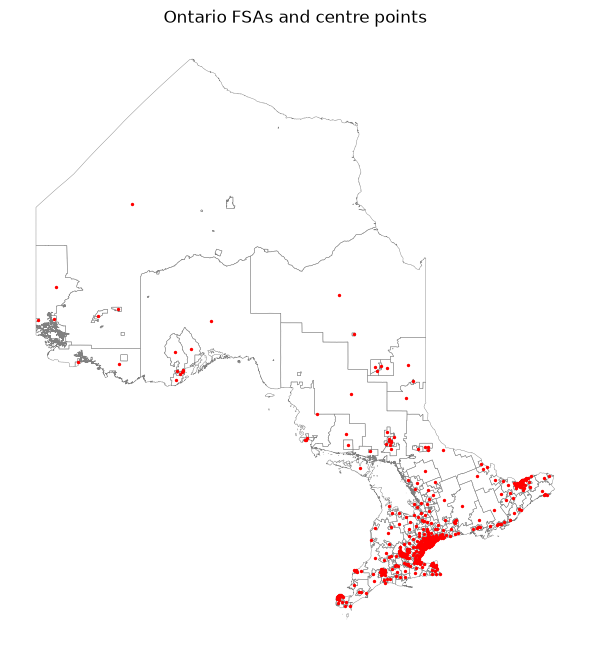

In [2]:
"""
Step 1: Ontario FSA polygons and centre points

Source: StatCan 2021 FSA boundaries (simplified), [sachijay/canada_maps](https://github.com/sachijay/canada_maps).
Fixes the mislabelled CRS (actually EPSG:3347), keeps Ontario (K, L, M, N, P), and saves the
polygons plus one inside-the-polygon point per FSA. Expect 520 FSAs.
"""
SRC = ("https://raw.githubusercontent.com/sachijay/canada_maps/main/"
       "exported_files/forward_sortation_areas_simplified.geojson")

r = requests.get(SRC, timeout=120); r.raise_for_status()
if r.text.startswith("version https://git-lfs"):                 # Git LFS pointer → real file
    r = requests.get(SRC.replace("raw.githubusercontent.com",
                                 "media.githubusercontent.com/media"), timeout=120)
    r.raise_for_status()
(DATA / "fsa_canada_simplified.geojson").write_bytes(r.content)

fsa = gpd.read_file(DATA / "fsa_canada_simplified.geojson")
if abs(fsa.total_bounds).max() > 1000:                           # coordinates are metres
    fsa = fsa.set_crs(epsg=3347, allow_override=True)

on = fsa[fsa["CFSAUID"].str[0].isin(list("KLMNP"))][["CFSAUID", "geometry"]]
on = on.rename(columns={"CFSAUID": "FSA"}).reset_index(drop=True)
on["geometry"] = on.geometry.make_valid()

poly = on.to_crs(epsg=4326)
poly.to_file(DATA / "ontario_fsa_polygons.gpkg", driver="GPKG")

pts = on.copy()
pts["geometry"] = pts.geometry.representative_point()            # always inside the FSA
cent = pts.to_crs(epsg=4326)
cent["lon"], cent["lat"] = cent.geometry.x.round(4), cent.geometry.y.round(4)
cent.to_file(DATA / "ontario_fsa_centroids.gpkg", driver="GPKG")

print(len(poly), "FSAs | bounds:", poly.total_bounds.round(2))
print("points inside polygon:", cent.within(poly).sum(), "/", len(cent))

ax = poly.plot(figsize=(8, 8), edgecolor="grey", facecolor="none", linewidth=0.3)
cent.plot(ax=ax, markersize=2, color="red")
ax.set_title("Ontario FSAs and centre points"); ax.set_axis_off()

In [3]:
"""
Copernicus setup

Sets the date range and connects to Copernicus (key from `~/.cdsapirc`).
`read_cds_csv` reads one downloaded file and converts temperature from Kelvin to °C.
"""

import cdsapi, zipfile

START = "2018-01-01"
END   = "2026-09-01"

client = cdsapi.Client()

def read_cds_csv(path):
    """Read a CDS time-series CSV (zipped or not) into time_utc + temp_c."""
    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path) as z:
            name = [n for n in z.namelist() if n.endswith(".csv")][0]
            df = pd.read_csv(z.open(name))
    else:
        df = pd.read_csv(path)
    tcol = [c for c in df.columns if "time" in c.lower()][0]
    vcol = [c for c in df.columns if c.lower() in ("t2m", "2m_temperature")][0]
    return pd.DataFrame({
        "time_utc": pd.to_datetime(df[tcol]),
        "temp_c": (df[vcol] - 273.15).astype("float32"),
    })

2026-10-07 07:39:47,228 INFO [2026-10-06T00:00:00Z] The [CDS Terms of Use](https://cds.climate.copernicus.eu/disclaimer-privacy) will be updated on 28 October 2026. Continued use of Copernicus Products and Services through the CDS after this date constitutes acceptance of the updated terms. If you do not accept the change, please [contact ECMWF Support](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202) before 27 October 2026.
 **[More information about the upcoming change.](https://forum.ecmwf.int/t/upcoming-cds-terms-of-use-change/15374)**


In [4]:
"""
Download temperature per grid cell

Maps each FSA to its ERA5-Land grid cell (0.1°, ~9 km); FSAs in the same cell share one download.
Downloads each cell's full hourly series, 2 at a time, saving one file per cell. Re-run to resume or retry failures.
"""

from concurrent.futures import ThreadPoolExecutor, as_completed

CELLS = DATA / "era5land_cells"; CELLS.mkdir(exist_ok=True)

cent = gpd.read_file(DATA / "ontario_fsa_centroids.gpkg")
cent["cell_lat"] = cent["lat"].round(1)
cent["cell_lon"] = cent["lon"].round(1)
cent["cell"] = cent["cell_lat"].map("{:.1f}".format) + "_" + cent["cell_lon"].map("{:.1f}".format)
cent[["FSA", "cell", "cell_lat", "cell_lon"]].to_csv(DATA / "fsa_to_cell.csv", index=False)

cells = cent.drop_duplicates("cell")[["cell", "cell_lat", "cell_lon"]]
todo = cells[~cells["cell"].apply(lambda c: (CELLS / f"{c}.parquet").exists())]

print(f"{len(cent)} FSAs → {len(cells)} grid cells | {len(todo)} to download")

def get_cell(row, tries=5):
    tmp = CELLS / f"{row.cell}.tmp"
    for attempt in range(tries):
        try:
            client.retrieve("reanalysis-era5-land-timeseries", {
                "variable": ["2m_temperature"],
                "location": {"longitude": float(row.cell_lon), "latitude": float(row.cell_lat)},
                "date": [f"{START}/{END}"],
                "data_format": "csv",
            }).download(str(tmp))
            read_cds_csv(tmp).to_parquet(CELLS / f"{row.cell}.parquet", index=False)
            tmp.unlink()
            return row.cell
        except Exception as e:
            if "temporarily limited" in str(e) and attempt < tries - 1:
                time.sleep(60 * (attempt + 1))      # wait 1, 2, 3, 4 min, then retry
            else:
                raise

done = 0
with ThreadPoolExecutor(max_workers=2) as pool:
    futures = {pool.submit(get_cell, r): r.cell for r in todo.itertuples()}
    for f in as_completed(futures):
        try:
            f.result(); done += 1
            print(f"{done}/{len(todo)} {futures[f]}")
        except Exception as e:
            print(f"FAILED {futures[f]}: {e}")

520 FSAs → 282 grid cells | 0 to download


In [5]:
"""
Combine into one FSA-level file

Joins each FSA to its cell's temperatures and adds fixed EST (UTC−5) time.
Saves `data/fsa_temperature_hourly.parquet` (~520 FSAs × ~76,000 hours).
"""
lookup = pd.read_csv(DATA / "fsa_to_cell.csv")
temps = pd.concat(
    [pd.read_parquet(f).assign(cell=f.stem) for f in sorted(CELLS.glob("*.parquet"))],
    ignore_index=True)

weather = lookup[["FSA", "cell"]].merge(temps, on="cell")
weather["time_est"] = weather["time_utc"] - pd.Timedelta(hours=5)    # fixed EST
weather["FSA"] = weather["FSA"].astype("category")
weather = weather[["FSA", "time_utc", "time_est", "temp_c"]]
weather.to_parquet(DATA / "fsa_temperature_hourly.parquet", index=False)

print(weather.shape, weather["FSA"].nunique(), "FSAs |", weather["temp_c"].isna().sum(), "missing")
print(weather["time_utc"].min(), "→", weather["time_utc"].max())

(39511680, 4) 520 FSAs | 0 missing
2018-01-01 00:00:00 → 2026-09-01 23:00:00


In [6]:
weather = pd.read_parquet(DATA / "fsa_temperature_hourly.parquet")
weather.head()

,FSA,time_utc,time_est,temp_c
0,K0A,2018-01-01 00:00:00,2017-12-31 19:00:00,-22.424810
1,K0A,2018-01-01 01:00:00,2017-12-31 20:00:00,-22.880529
2,K0A,2018-01-01 02:00:00,2017-12-31 21:00:00,-23.386921
3,K0A,2018-01-01 03:00:00,2017-12-31 22:00:00,-23.947821
4,K0A,2018-01-01 04:00:00,2017-12-31 23:00:00,-24.532141


In [7]:
"""
Verify the temperature data

Checks the final file for completeness (all 520 FSAs, every hour, no duplicates, gaps, or missing values),
correct units and time zone, and physical sense (seasons, north vs south, daily cycle).
Each line prints OK or FAIL.
"""

w = pd.read_parquet(DATA / "fsa_temperature_hourly.parquet")
poly = gpd.read_file(DATA / "ontario_fsa_polygons.gpkg")
expected_hours = len(pd.date_range("2018-01-01 00:00", "2026-09-01 23:00", freq="h"))

def check(name, ok, detail=""):
    print(f"{'OK  ' if ok else 'FAIL'} {name} {detail}")

# 1. Every FSA from the map is present, and nothing extra
fsas = set(w["FSA"].astype(str))
check("all 520 FSAs present", fsas == set(poly["FSA"]), f"({len(fsas)} found)")

# 2. Every FSA has every hour exactly once
hours = w.groupby("FSA", observed=True).size()
check("hours per FSA", (hours == expected_hours).all(),
      f"(expected {expected_hours:,}, min {hours.min():,}, max {hours.max():,})")
check("no duplicate FSA-hours", not w.duplicated(["FSA", "time_utc"]).any())

# 3. No gaps: consecutive hours are exactly 1 h apart
one = w[w["FSA"] == w["FSA"].iloc[0]].sort_values("time_utc")["time_utc"]
check("no time gaps", (one.diff().dropna() == pd.Timedelta("1h")).all())

# 4. No missing values
check("no missing temperatures", w["temp_c"].notna().all())

# 5. Temperatures in a realistic range for Ontario
lo, hi = w["temp_c"].min(), w["temp_c"].max()
check("temperature range plausible", -50 < lo and hi < 45, f"(min {lo:.1f} °C, max {hi:.1f} °C)")

# 6. EST is exactly UTC − 5 h
check("EST = UTC − 5", ((w["time_utc"] - w["time_est"]) == pd.Timedelta("5h")).all())

# 7. Seasons make sense: January colder than July everywhere
m = w.assign(month=w["time_est"].dt.month).groupby(["FSA", "month"], observed=True)["temp_c"].mean().unstack()
check("January colder than July in every FSA", (m[1] < m[7]).all(),
      f"(Jan avg {m[1].mean():.1f} °C, Jul avg {m[7].mean():.1f} °C)")

# 8. North colder than south (Sudbury P3E vs Windsor N9A)
if {"P3E", "N9A"} <= fsas:
    check("north colder than south", m.loc["P3E"].mean() < m.loc["N9A"].mean(),
          f"(P3E {m.loc['P3E'].mean():.1f} °C, N9A {m.loc['N9A'].mean():.1f} °C)")

# 9. Daily cycle: afternoon warmer than early morning
h = w.assign(hour=w["time_est"].dt.hour).groupby("hour")["temp_c"].mean()
check("afternoon warmer than night", h[15] > h[5], f"(05:00 {h[5]:.1f} °C, 15:00 {h[15]:.1f} °C)")

OK   all 520 FSAs present (520 found)
OK   hours per FSA (expected 75,984, min 75,984, max 75,984)
OK   no duplicate FSA-hours 
OK   no time gaps 
OK   no missing temperatures 
OK   temperature range plausible (min -38.9 °C, max 37.8 °C)
OK   EST = UTC − 5 
OK   January colder than July in every FSA (Jan avg -5.6 °C, Jul avg 22.1 °C)
OK   north colder than south (P3E 5.7 °C, N9A 10.7 °C)
OK   afternoon warmer than night (05:00 5.9 °C, 15:00 11.6 °C)
